**Все представленные материалы взяты из открытых источников в интернете плюс искусственный интеллект.**

# Линейная модель (регрессия)

Будем работать с данными о рекламе и продажах. У нас есть 200 рынков. На каждом из них мы инвестировали в разную рекламу какую-то сумму.

* TV - доллары, потраченные на ТВ рекламу для одного продукта на данном рынке (в тысячах долларов)
* Radio - доллары, потраченные на радио рекламу
Newspaper - доллары, потраченные на рекламу в газетах
* Area - в какой зоне происходила реклама (сельская, пригород, город)
* Sales - продажи одного продукта на данном рынке (в тысячах)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/hse-econ-data-science/andan2024/refs/heads/main/sem05_intro_ml/Advertising.csv')

In [3]:
df

,TV,Radio,Newspaper,Sales,Area
0,230.1,37.8,69.2,22.1,suburban
1,44.5,39.3,45.1,10.4,urban
2,17.2,45.9,69.3,9.3,rural
3,151.5,41.3,58.5,18.5,rural
4,180.8,10.8,58.4,12.9,suburban
...,...,...,...,...,...
195,38.2,3.7,13.8,7.6,suburban
196,94.2,4.9,8.1,9.7,suburban
197,177.0,9.3,6.4,12.8,rural
198,283.6,42.0,66.2,25.5,suburban


<Axes: ylabel='Frequency'>

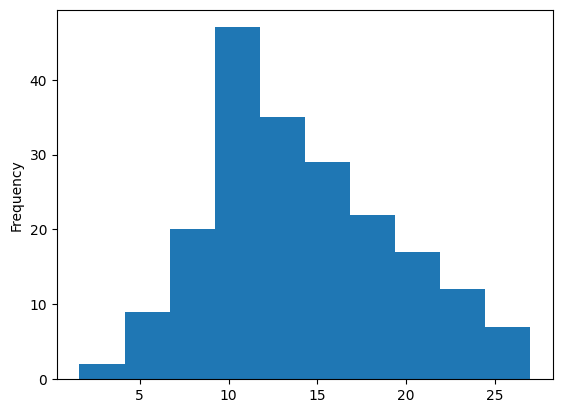

In [4]:
df.Sales.plot(kind='hist')

<Axes: ylabel='Frequency'>

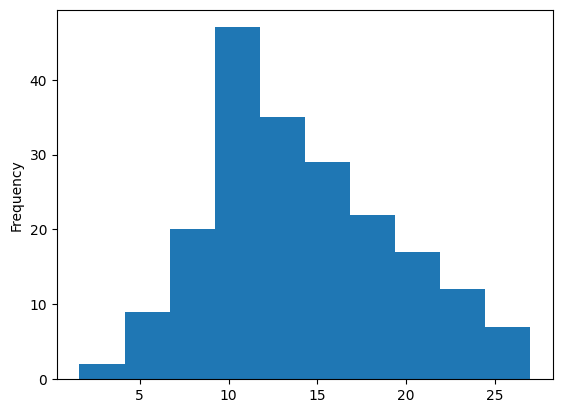

In [5]:
df.Sales.plot.hist()

<Axes: xlabel='Sales', ylabel='Count'>

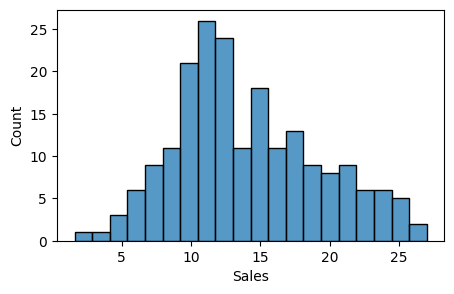

In [6]:
plt.figure(figsize=(5,3))
sns.histplot(df.Sales, bins=20)

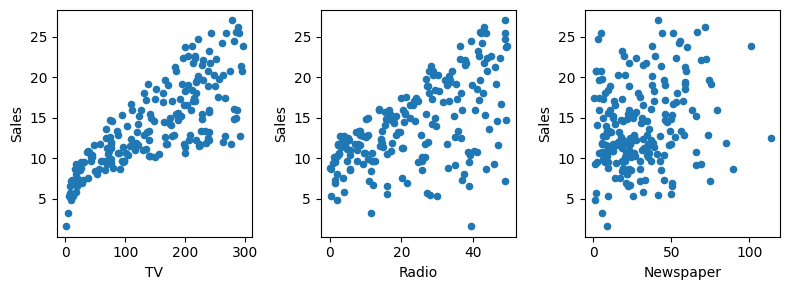

In [7]:
fig, axs = plt.subplots(1, 3)

df.plot(kind='scatter', x='TV', y='Sales', ax=axs[0], figsize=(8, 3))
df.plot(kind='scatter', x='Radio', y='Sales', ax=axs[1])
df.plot(kind='scatter', x='Newspaper', y='Sales', ax=axs[2]);

plt.tight_layout()

In [8]:
df[['TV', 'Radio', 'Newspaper']].corrwith(df['Sales'])

,0
TV,0.782224
Radio,0.576223
Newspaper,0.228299


In [9]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0
Area,0


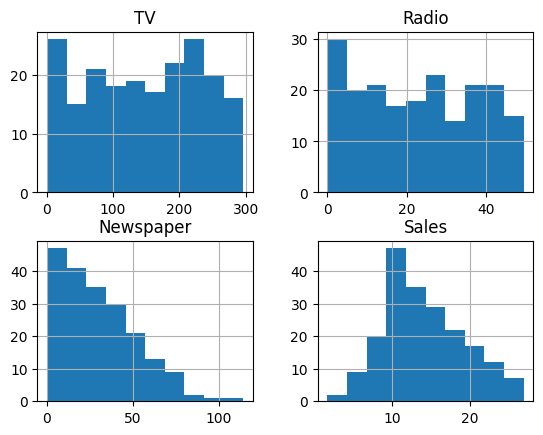

In [10]:
df.hist();

In [11]:
df['Area'].value_counts()

,count
Area,
rural,71
suburban,69
urban,60


In [12]:
pd.get_dummies(df['Area'], dtype=int).head()

,rural,suburban,urban
0,0,1,0
1,0,0,1
2,1,0,0
3,1,0,0
4,0,1,0


In [13]:
pd.get_dummies(df['Area'], dtype=int, drop_first=True).head()

,suburban,urban
0,1,0
1,0,1
2,0,0
3,0,0
4,1,0


In [14]:
df = pd.get_dummies(df, dtype=int, drop_first=True)
df

,TV,Radio,Newspaper,Sales,Area_suburban,Area_urban
0,230.1,37.8,69.2,22.1,1,0
1,44.5,39.3,45.1,10.4,0,1
2,17.2,45.9,69.3,9.3,0,0
3,151.5,41.3,58.5,18.5,0,0
4,180.8,10.8,58.4,12.9,1,0
...,...,...,...,...,...,...
195,38.2,3.7,13.8,7.6,1,0
196,94.2,4.9,8.1,9.7,1,0
197,177.0,9.3,6.4,12.8,0,0
198,283.6,42.0,66.2,25.5,1,0


In [15]:
from sklearn.model_selection import train_test_split

In [16]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

In [17]:
y_train = df_train['Sales']
y_test = df_test['Sales']

X_train = df_train.drop('Sales', axis=1)
X_test = df_test.drop('Sales', axis=1)

In [18]:
feature_names = df_train.drop('Sales', axis=1).columns
feature_names

Index(['TV', 'Radio', 'Newspaper', 'Area_suburban', 'Area_urban'], dtype='object')

In [19]:
X_train.shape, X_test.shape

((160, 5), (40, 5))

In [20]:
y_mean = np.mean(y_train)
y_pred_naive = np.ones(len(y_test)) * y_mean

In [21]:
from sklearn import metrics

In [22]:
print('RMSE:', "%.2f" % np.sqrt(metrics.mean_squared_error(y_test, y_pred_naive)))

RMSE: 5.63


In [23]:
from sklearn.linear_model import LinearRegression

model_regression = LinearRegression()

model_regression.fit(X_train, y_train)

y_pred_regression = model_regression.predict(X_test)

In [24]:
print('RMSE:', "%.2f" % np.sqrt(metrics.mean_squared_error(y_test, y_pred_regression)))

RMSE: 1.80


In [25]:
model_regression.coef_

array([ 0.04482017,  0.18995499,  0.00281706, -0.22006653, -0.11379965])

In [26]:
model_regression.intercept_

np.float64(3.0534457425468595)

In [27]:
feature_names

Index(['TV', 'Radio', 'Newspaper', 'Area_suburban', 'Area_urban'], dtype='object')

In [28]:
X_test.iloc[0].to_dict()

{'TV': 163.3,
 'Radio': 31.6,
 'Newspaper': 52.9,
 'Area_suburban': 0.0,
 'Area_urban': 1.0}

In [29]:
X_test.iloc[0].to_numpy()

array([163.3,  31.6,  52.9,   0. ,   1. ])

In [30]:
array = np.array([[10, 10, 10, 1.0, 0.0]])

In [31]:
answer = model_regression.predict(array)
answer

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([5.20930142])

In [32]:
(0.04482017 * 10) + (0.18995499 * 10) + (0.00281706 * 10) + \
(-0.22006653 * 1.0) + (-0.11379965 * 0.0) + 3.0534457425468595

5.209301412546859

In [33]:
np.dot(model_regression.coef_, np.squeeze(array)) + model_regression.intercept_

np.float64(5.209301417534311)

Наше уравнение:

* y = x1 * w1 + x2 * w2 + x3 * w2 + x4 * w4 + x5 * w5 + w0

* Sales = x1 * w1 + x2 * w2 + x3 * w2 + x4 * w4 + x5 * w5 + w0

* Sales = TV * w1 + Radio * w2 + Newspaper * w2 + Area_suburban * w4 + Area_urban * w5 + w0

* Sales = TV * 0.045 + Radio * 0.189 + Newspaper * 0.003 + Area_suburban * (-0.220) + Area_urban * (-0.114) + 3.053

# Метод ближайших соседей (kNN), регрессия

![knn](https://www.jcchouinard.com/wp-content/uploads/2021/08/image-8.png)

In [34]:
from sklearn.neighbors import KNeighborsRegressor

model_knn = KNeighborsRegressor(n_neighbors=20)

model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

print('RMSE:', "%.2f" % np.sqrt(metrics.mean_squared_error(y_test, y_pred_knn)))

RMSE: 2.11


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [36]:
model_knn = KNeighborsRegressor(n_neighbors=20)
model_knn.fit(X_train_scale, y_train)
y_pred_knn = model_knn.predict(X_test_scale)

print('RMSE:', "%.2f" % np.sqrt(metrics.mean_squared_error(y_test, y_pred_knn)))

RMSE: 3.06


In [37]:
for k in range(1, 30):
    y_pred = KNeighborsRegressor(n_neighbors=k).fit(X_train, y_train).predict(X_test)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    print(f"k = {k}; rmse = {rmse:.2f}")

k = 1; rmse = 1.95
k = 2; rmse = 1.78
k = 3; rmse = 1.74
k = 4; rmse = 1.73
k = 5; rmse = 1.68
k = 6; rmse = 1.80
k = 7; rmse = 1.65
k = 8; rmse = 1.67
k = 9; rmse = 1.64
k = 10; rmse = 1.65
k = 11; rmse = 1.72
k = 12; rmse = 1.79
k = 13; rmse = 1.85
k = 14; rmse = 1.92
k = 15; rmse = 2.00
k = 16; rmse = 2.01
k = 17; rmse = 2.01
k = 18; rmse = 2.05
k = 19; rmse = 2.06
k = 20; rmse = 2.11
k = 21; rmse = 2.16
k = 22; rmse = 2.17
k = 23; rmse = 2.24
k = 24; rmse = 2.31
k = 25; rmse = 2.35
k = 26; rmse = 2.35
k = 27; rmse = 2.36
k = 28; rmse = 2.43
k = 29; rmse = 2.48


In [38]:
for k in range(1, 30):
    y_pred = KNeighborsRegressor(n_neighbors=k).fit(X_train_scale, y_train).predict(X_test_scale)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    print(f"k = {k}; rmse = {rmse:.2f}")

k = 1; rmse = 2.29
k = 2; rmse = 2.50
k = 3; rmse = 2.61
k = 4; rmse = 2.66
k = 5; rmse = 2.55
k = 6; rmse = 2.49
k = 7; rmse = 2.58
k = 8; rmse = 2.59
k = 9; rmse = 2.55
k = 10; rmse = 2.60
k = 11; rmse = 2.74
k = 12; rmse = 2.76
k = 13; rmse = 2.77
k = 14; rmse = 2.83
k = 15; rmse = 2.85
k = 16; rmse = 2.86
k = 17; rmse = 2.87
k = 18; rmse = 3.00
k = 19; rmse = 3.04
k = 20; rmse = 3.06
k = 21; rmse = 3.12
k = 22; rmse = 3.11
k = 23; rmse = 3.11
k = 24; rmse = 3.11
k = 25; rmse = 3.11
k = 26; rmse = 3.13
k = 27; rmse = 3.14
k = 28; rmse = 3.17
k = 29; rmse = 3.17


# Линейная модель (логистическая регрессия - классификация)

In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
df = pd.read_csv('https://raw.githubusercontent.com/hse-econ-data-science/andan2024/refs/heads/main/sem08_logreg/telecom_churn.csv')
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   

Описание переменных:

* State — Буквенный код штата
vAccount length — Как долго клиент обслуживается компанией
* Area code — Префикс номера телефона
* International plan — Международный роуминг (подключен/не подключен)
* Voice mail plan — Голосовая почта (подключена/не подключена)
* Number vmail messages — Количество голосовых сообщений
* Total day minutes — Общая длительность разговоров днем
* Total day calls — Общее количество звонков днем
* Total day charge — Общая сумма оплаты за услуги днем
* Total eve minutes — Общая длительность разговоров вечеромй
* Total eve calls — Общее количество звонков вечером
* Total eve charge — Общая сумма оплаты за услуги вечером
* Total night minutes — Общая длительность разговоров ночью
* Total night calls — Общее количество звонков ночью
* Total night charge — Общая сумма оплаты за услуги ночью
* Total intl minutes — Общая длительность международных разговоров
* Total intl calls — Общее количество международных разговоров
* Total intl charge — Общая сумма оплаты за международные разговоры
* Customer service calls — Число обращений в сервисный центр
* Целевая переменная: Churn — Признак оттока, бинарный признак (1 – потеря клиента, то есть отток).

In [42]:
categorical_features = ['State', 'Area code', 'International plan', 'Voice mail plan']

numeric_features = [
    'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge',
    'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes',
    'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls',
    'Total intl charge', 'Customer service calls', 'Account length'
]

target = 'Churn'

<Axes: >

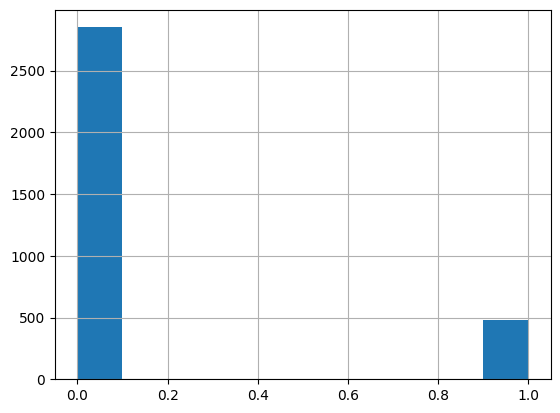

In [43]:
df[target].astype(int).hist()

In [44]:
df.isnull().sum()

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


In [45]:
df[numeric_features].describe()

,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Account length
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856,101.064806
std,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491,39.822106
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000,74.000000
50%,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000,101.000000
75%,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000,127.000000
max,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000,243.000000


In [46]:
from sklearn.model_selection import train_test_split

# опция stratify делает разбиение на тест и трэйн сбалансированным по Churn
df_train, df_test = train_test_split(df, test_size=0.2, stratify=df['Churn'])

In [47]:
y_train = df_train['Churn']
y_test = df_test['Churn']
X_train = df_train.drop('Churn', axis=1)
X_test = df_test.drop('Churn', axis=1)

In [48]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

column_transformer = ColumnTransformer([
    ('scaling', StandardScaler(), numeric_features),
    ('ohe', OneHotEncoder(handle_unknown="ignore", drop="first",
                         min_frequency=0.01), categorical_features)
])

In [49]:
X_train.shape

(2666, 19)

In [50]:
column_transformer.fit_transform(X_train).shape

(2666, 69)

In [51]:
from sklearn.metrics import accuracy_score
y_pred = np.zeros_like(y_test)
accuracy_score(y_test, y_pred)

0.8545727136431784

In [52]:
from sklearn.model_selection import GridSearchCV

model_lr = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', LogisticRegression())
])

alphas = np.logspace(-2, 4, 20)

searcher_lr = GridSearchCV(model_lr, [{"regression__C": alphas}],
                        scoring="roc_auc", cv=10, n_jobs=-1)
searcher_lr.fit(X_train, y_train)

best_alpha = searcher_lr.best_params_["regression__C"]

Best alpha = 0.1833


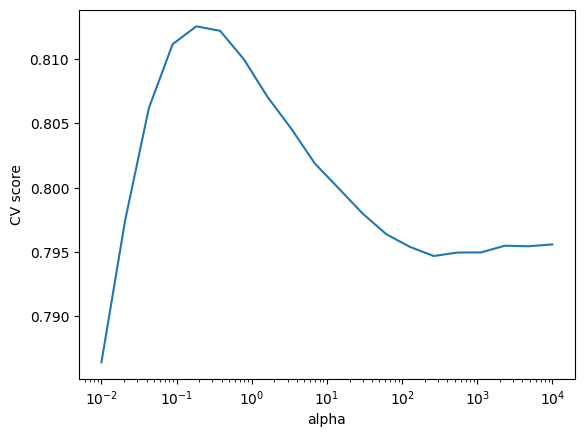

In [53]:
print("Best alpha = %.4f" % best_alpha)

plt.plot(alphas, searcher_lr.cv_results_["mean_test_score"])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("CV score");

In [54]:
y_pred = searcher_lr.predict(X_test)
accuracy_score(y_test, y_pred)

0.8605697151424287

In [55]:
from sklearn.metrics import roc_auc_score

p_pred = searcher_lr.predict_proba(X_test)
roc_auc_score(y_test, p_pred[:,-1])

np.float64(0.8115210707180323)

In [56]:
from sklearn.ensemble import RandomForestClassifier

model_rf = Pipeline(steps=[
    ('oheand_scaling', column_transformer),
    ('rf', RandomForestClassifier(n_estimators=1000))
])

model_rf.fit(X_train, y_train)

p_pred = model_rf.predict_proba(X_test)
roc_auc_score(y_test, p_pred[:,-1])

np.float64(0.9176523783686019)

**Все представленные материалы взяты из открытых источников в интернете плюс искусственный интеллект.**